# Polynomial regression for the Runge function
**Main design** 100 equally spaced x in [-1,1], Gaussian sigma=0.1, seed=2026, degrees 0-15, exploratory 80/20 split.

In [2]:
# Config
config_seed = 2026
config_n = 100
config_sigma = 0.1
config_test_size = 0.2
config_max_degree = 15

## Part a) Ordinary least squares


In [3]:
import numpy as np
from sklearn.model_selection import train_test_split

def runge(x):
    """Runge function."""
    return 1.0 / (1.0 + 25.0 * x**2)

def generate_data(n=config_n, sigma=config_sigma, seed=config_seed):
    """Generate x in [-1, 1] and observations y = f(x) + noise where noise ~ N(0, sigma^2)."""
    x = np.linspace(-1, 1, n)
    y_actual = runge(x)
    epsilon = np.random.default_rng(seed).normal(0, sigma, size=n)
    return x, y_actual + epsilon, y_actual

def scale_x(x_train, x_test):
    """Standardize x using training data only."""
    mean_x = np.mean(x_train)
    std_dev_x = np.std(x_train)
    x_train_scaled = (x_train - mean_x) / std_dev_x
    x_test_scaled = (x_test - mean_x) / std_dev_x
    return x_train_scaled, x_test_scaled, mean_x, std_dev_x

def design_matrix(x, degree, intercept=True):
    """Construct X = [1, x, x^2, ..., x^degree] (drop the 1 if intercept=False)"""
    start = 0 if intercept else 1
    return np.vstack([x**p for p in range(start, degree + 1)]).T

def ols(X, y):
    """Solve the OLS problem theta = (X^T X)^(-1) X^T y)"""
    return np.linalg.pinv(X) @ y

def predict(X, theta):
    """Prediction"""
    return X @ theta

def mse(y, prediction):
    """Mean squared error."""
    return float(np.mean((np.asarray(y) - prediction) **2))

def r2(y, prediction):
    """Coefficient of determination"""
    denominator = np.sum((y - np.mean(y)) **2)
    return float(1 - np.sum((y - prediction) ** 2) / denominator)

def polynomial_regression(n=config_n, sigma=config_sigma, max_degree=config_max_degree, test_size=config_test_size, seed=config_seed):
    """Run polynomial regression for degrees 0, ..., max_degree"""
    x, y, y_actual = generate_data(n, sigma, seed)

    # Split data using the same indices
    x_train, x_test, y_train, y_test, y_train_actual, y_test_actual = train_test_split(x, y, y_actual, test_size=test_size, random_state=seed)

    # Scale x using only training data
    x_train_scaled, x_test_scaled, mean_x, std_dev_x = scale_x(x_train, x_test)

    # List polynomial degrees to test
    degrees = np.arange(max_degree + 1)

    # Results
    train_mse = []
    test_mse = []
    train_r2 = []
    test_r2 = []
    test_mse_actual = []
    test_r2_actual = []
    thetas = []

    for degree in degrees:
        X_train = design_matrix(x_train_scaled, degree)
        X_test = design_matrix(x_test_scaled, degree)

        # OLS
        theta = ols(X_train, y_train)

        # Predictions
        y_train_pred = predict(X_train, theta)
        y_test_pred = predict(X_test, theta)

        # Add metrics to result holders
        train_mse.append(mse(y_train, y_train_pred))
        test_mse.append(mse(y_test, y_test_pred))
        train_r2.append(r2(y_train, y_train_pred))
        test_r2.append(r2(y_test, y_test_pred))

        # Metrics against the underlying noiseless functions
        test_mse_actual.append(mse(y_test_actual, y_test_pred))
        test_r2_actual.append(r2(y_test_actual, y_test_pred))

        thetas.append(theta)

    # Pad coefficient arrays with Nan so that they have the same length
    thetas_padded = np.full((max_degree + 1, max_degree + 1), np.nan)
    for deg, coefficients in enumerate(thetas):
        thetas_padded[deg, :len(coefficients)] = coefficients

    return {
        "degrees": degrees,
        "train_mse": np.array(train_mse),
        "test_mse": np.array(test_mse),
        "train_r2": np.array(train_r2),
        "test_r2": np.array(test_r2),
        "test_mse_actual": np.array(test_mse_actual),
        "test_r2_actual": np.array(test_r2_actual),
        "theta": thetas_padded,
        "x_train": x_train,
        "x_test": x_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_test_actual": y_test_actual,
        "mean_x": mean_x,
        "std_dev_x": std_dev_x
    }


### Experiment

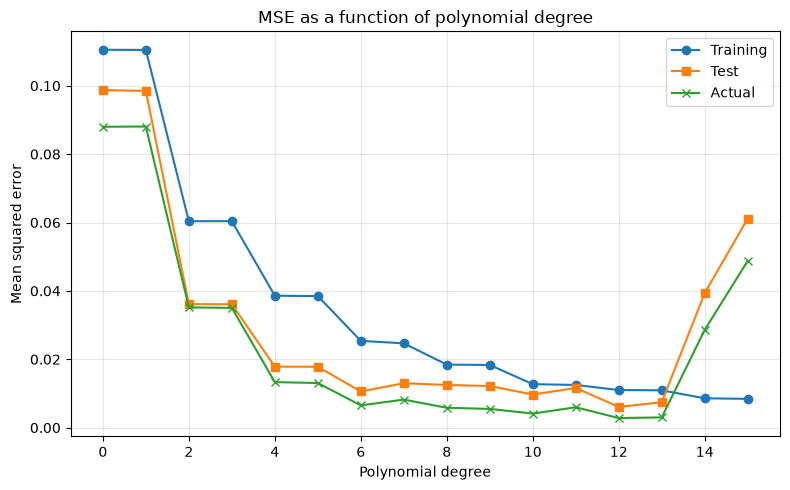

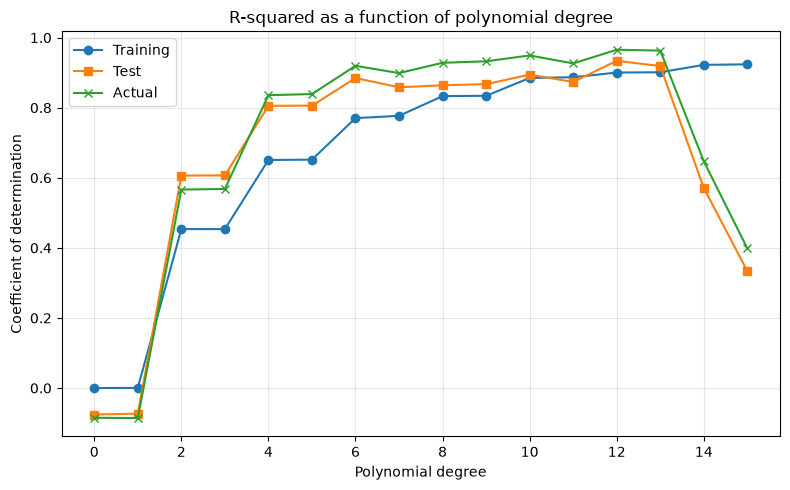

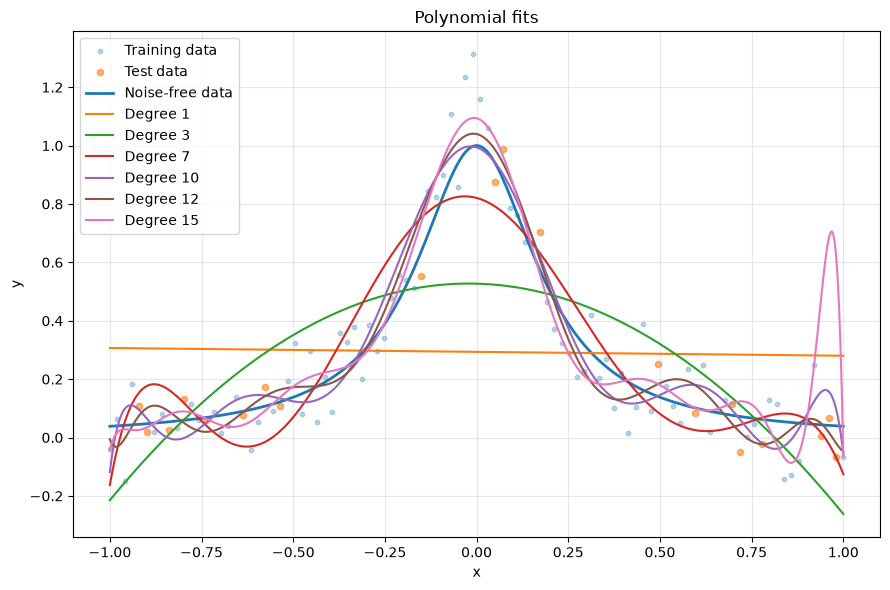

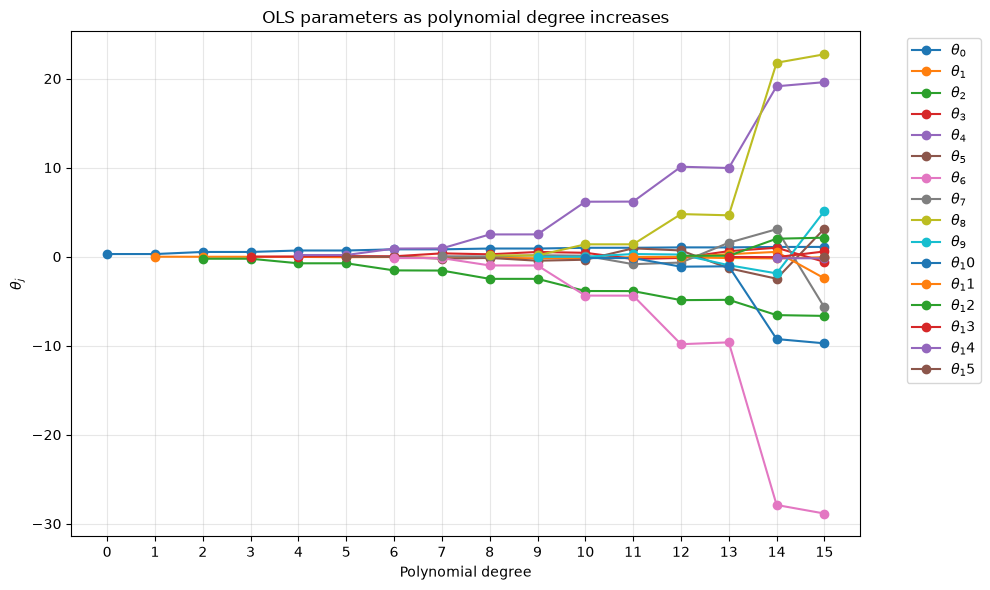


Results:
---------------------------------------------------------------------------
  Degree      Train MSE       Test MSE       Train R2        Test R2
---------------------------------------------------------------------------
       0       0.110524       0.098739       0.000000      -0.075725
       1       0.110470       0.098486       0.000485      -0.072965
       2       0.060390       0.036142       0.453600       0.606251
       3       0.060388       0.036081       0.453618       0.606914
       4       0.038588       0.017857       0.650861       0.805457
       5       0.038487       0.017814       0.651774       0.805919
       6       0.025386       0.010585       0.770313       0.884679
       7       0.024668       0.013008       0.776812       0.858278
       8       0.018443       0.012482       0.833134       0.864016
       9       0.018342       0.012189       0.834041       0.867209
      10       0.012719       0.009696       0.884925       0.894367
      11  

In [4]:
import matplotlib.pyplot as plt

result = polynomial_regression()
degrees = result["degrees"]

# Plot MSE
plt.figure(figsize=(8,5))
plt.plot(degrees, result["train_mse"], "o-", label="Training")
plt.plot(degrees, result["test_mse"], "s-", label="Test")
plt.plot(degrees, result["test_mse_actual"], "x-", label="Actual")

plt.xlabel("Polynomial degree")
plt.ylabel("Mean squared error")
plt.title("MSE as a function of polynomial degree")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot R squared
plt.figure(figsize=(8,5))
plt.plot(degrees, result["train_r2"], "o-", label="Training")
plt.plot(degrees, result["test_r2"], "s-", label="Test")
plt.plot(degrees, result["test_r2_actual"], "x-", label="Actual")

plt.xlabel("Polynomial degree")
plt.ylabel("Coefficient of determination")
plt.title("R-squared as a function of polynomial degree")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot fitted polynomial for selected degrees

x_plot = np.linspace(-1, 1, 500)
x_plot_scaled = (x_plot - result["mean_x"]) / result["std_dev_x"]

plt.figure(figsize=(9, 6))
plt.scatter(result["x_train"], result["y_train"], s=10, alpha=0.3, label="Training data")
plt.scatter(result["x_test"], result["y_test"], s=20, alpha=0.6, label="Test data")
plt.plot(x_plot, runge(x_plot), linewidth=2, label="Noise-free data")

for degree in [1, 3, 7, 10, 12, 15]:
    X_plot = design_matrix(x_plot_scaled, degree)
    theta = result["theta"][degree, :degree + 1]
    y_plot = predict(X_plot, theta)
    plt.plot(x_plot, y_plot, label=f"Degree {degree}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial fits")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot polynomial params theta
plt.figure(figsize=(10,6))

for j in range(result["theta"].shape[1]):
    plt.plot(degrees, result["theta"][:, j], marker="o", label=fr"$\theta_{j}$")

plt.xlabel("Polynomial degree")
plt.ylabel(r"$\theta_j$")
plt.title("OLS parameters as polynomial degree increases")
plt.xticks(degrees)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Print numerical results
print("\nResults:")
print("-" * 75)
print(
    f"{'Degree':>8}"
    f"{'Train MSE':>15}"
    f"{'Test MSE':>15}"
    f"{'Train R2':>15}"
    f"{'Test R2':>15}"
)
print("-" * 75)

for i, degree in enumerate(degrees):

    print(
        f"{degree:8d}"
        f"{result['train_mse'][i]:15.6f}"
        f"{result['test_mse'][i]:15.6f}"
        f"{result['train_r2'][i]:15.6f}"
        f"{result['test_r2'][i]:15.6f}"
    )


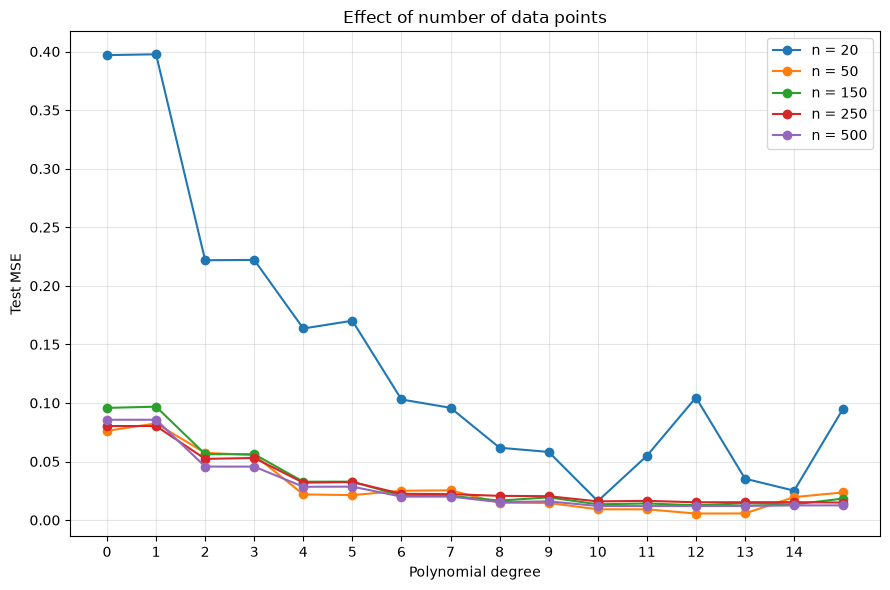

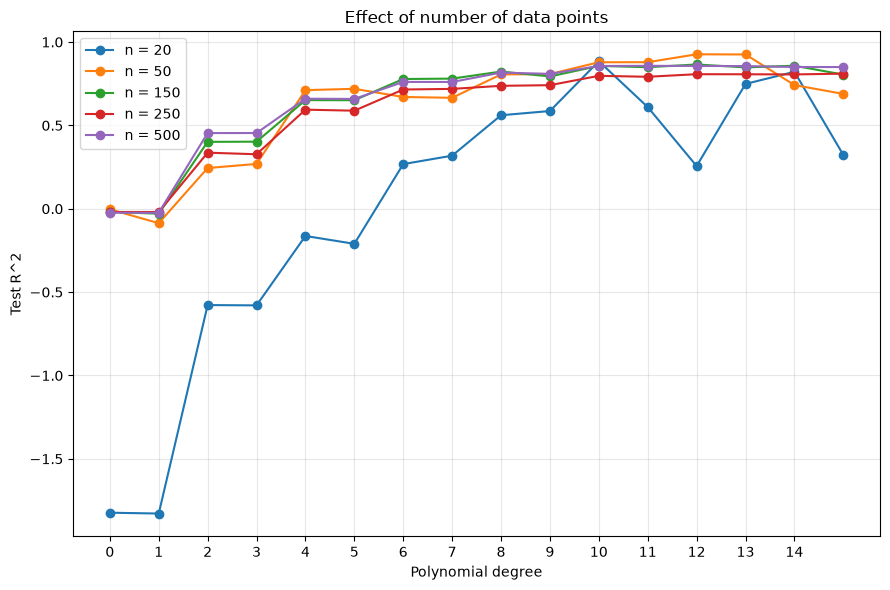

Sample-size exploratory minima (not independent test estimates):
n=20: degree=10, test MSE=0.016193
n=50: degree=12, test MSE=0.005584
n=150: degree=12, test MSE=0.012655
n=250: degree=15, test MSE=0.014924
n=500: degree=11, test MSE=0.011938


In [5]:
# Dependencies on number of data points

sample_sizes = [20, 50, 150, 250, 500]
size_results = {n: polynomial_regression(n=n) for n in sample_sizes}

plt.figure(figsize=(9, 6))

for n in sample_sizes:
    result = size_results[n]
    plt.plot(result["degrees"], result["test_mse"], marker="o", label=f"n = {n}")

plt.xlabel("Polynomial degree")
plt.ylabel("Test MSE")
plt.title("Effect of number of data points")
plt.xticks(range(15))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))

for n in sample_sizes:
    result = size_results[n]
    plt.plot(result["degrees"], result["test_r2"], marker="o", label=f"n = {n}")

plt.xlabel("Polynomial degree")
plt.ylabel("Test R^2")
plt.title("Effect of number of data points")
plt.xticks(range(15))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print("Sample-size exploratory minima (not independent test estimates):")
for n, sample_result in size_results.items():
    best = np.argmin(sample_result["test_mse"])
    print(f"n={n}: degree={sample_result['degrees'][best]}, test MSE={sample_result['test_mse'][best]:.6f}")

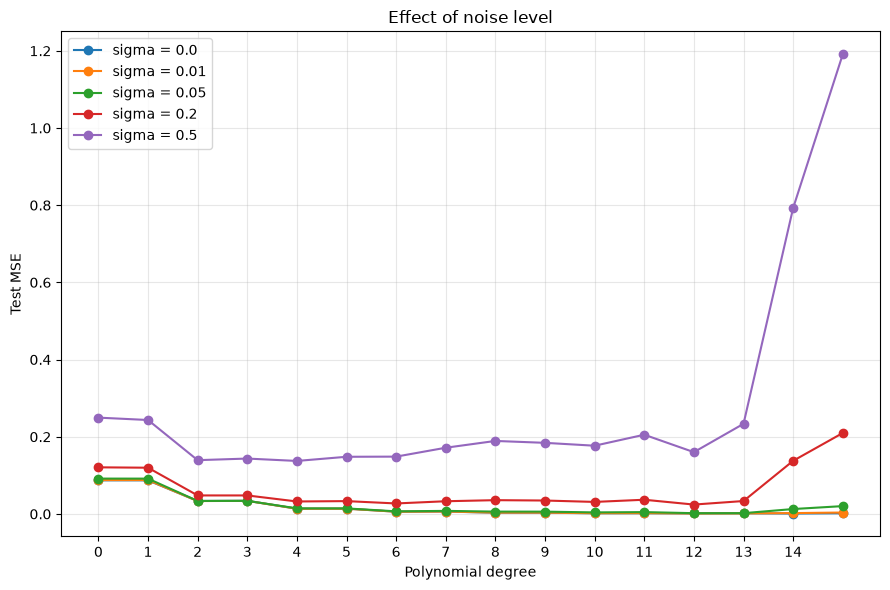

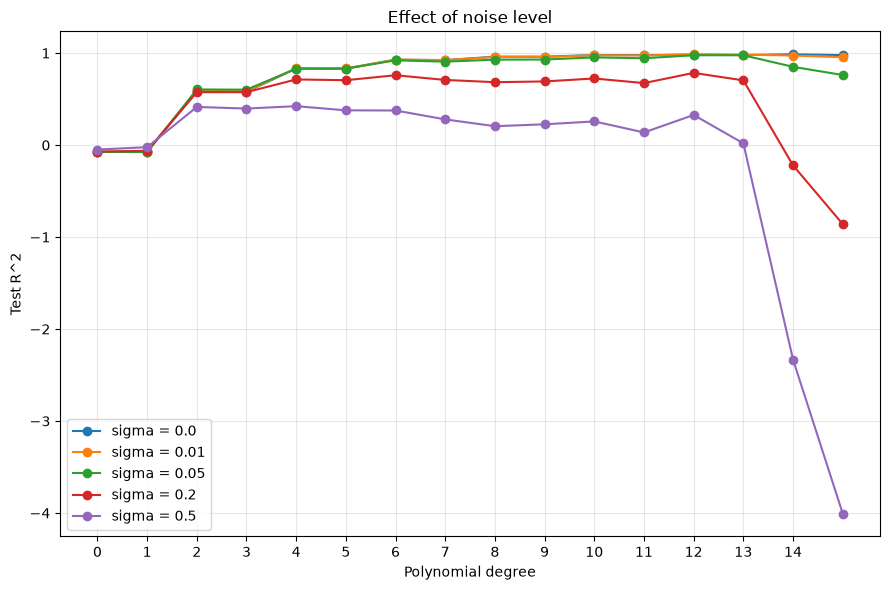

Noise-level exploratory minima (not independent test estimates):
sigma=0: degree=14, test MSE=0.001090
sigma=0.01: degree=12, test MSE=0.001201
sigma=0.05: degree=12, test MSE=0.002018
sigma=0.2: degree=12, test MSE=0.024332
sigma=0.5: degree=4, test MSE=0.137343


In [6]:
# Dependence on noise level
noise_levels = [0.0, 0.01, 0.05, 0.2, 0.5]
noise_results = {noise: polynomial_regression(sigma=noise) for noise in noise_levels}

plt.figure(figsize=(9, 6))

for noise in noise_levels:
    result = noise_results[noise]
    plt.plot(result["degrees"], result["test_mse"], marker="o", label=f"sigma = {noise}")

plt.xlabel("Polynomial degree")
plt.ylabel("Test MSE")
plt.title("Effect of noise level")
plt.xticks(range(15))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))

for noise in noise_levels:
    result = noise_results[noise]
    plt.plot(result["degrees"], result["test_r2"], marker="o", label=f"sigma = {noise}")

plt.xlabel("Polynomial degree")
plt.ylabel("Test R^2")
plt.title("Effect of noise level")
plt.xticks(range(15))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print("Noise-level exploratory minima (not independent test estimates):")
for noise, noise_result in noise_results.items():
    best = np.argmin(noise_result["test_mse"])
    print(f"sigma={noise:g}: degree={noise_result['degrees'][best]}, test MSE={noise_result['test_mse'][best]:.6f}")

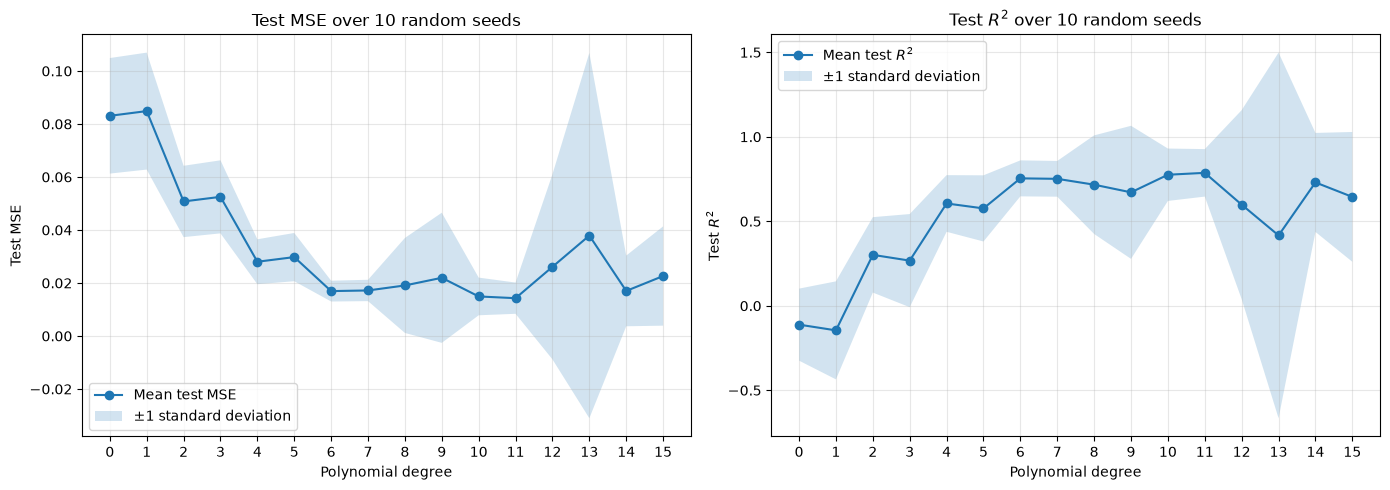

Ten-seed mean test MSE minimum: degree=11, mean=0.014270, SD=0.005893


In [7]:
# Repeat experiment for multiple seeds
n_seeds = 10
seeds = range(n_seeds)

seed_results = [
    polynomial_regression(seed=seed)
    for seed in seeds
]

degrees = seed_results[0]["degrees"]
test_mse = np.array([result["test_mse"] for result in seed_results])
test_r2 = np.array([result["test_r2"] for result in seed_results])
mse_mean = np.mean(test_mse, axis=0)
mse_std = np.std(test_mse, axis=0)
r2_mean = np.mean(test_r2, axis=0)
r2_std = np.std(test_r2, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(degrees, mse_mean, marker="o", label="Mean test MSE")
axes[0].fill_between(degrees, mse_mean - mse_std, mse_mean + mse_std, alpha=0.2, label="±1 standard deviation",)
axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("Test MSE")
axes[0].set_title(f"Test MSE over {n_seeds} random seeds")
axes[0].set_xticks(degrees)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(degrees, r2_mean, marker="o", label=r"Mean test $R^2$")
axes[1].fill_between(degrees, r2_mean - r2_std, r2_mean + r2_std, alpha=0.2, label="±1 standard deviation",)
axes[1].set_xlabel("Polynomial degree")
axes[1].set_ylabel(r"Test $R^2$")
axes[1].set_title(f"Test $R^2$ over {n_seeds} random seeds")
axes[1].set_xticks(degrees)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()
best_mean_degree = np.argmin(mse_mean)
print(f"Ten-seed mean test MSE minimum: degree={degrees[best_mean_degree]}, mean={mse_mean[best_mean_degree]:.6f}, SD={mse_std[best_mean_degree]:.6f}")


## Part b) Ridge regression

In [8]:
config_lambdas = [0.0, 1e-6, 1e-4, 1e-2, 0.1, 1.0]
def ridge(X, y, lmbda):
    """Return the closed-form Ridge estimate for a design matrix X"""
    if lmbda < 0:
        raise ValueError("Lambda must be non-negative.")
    penalty = np.eye(X.shape[1])
    penalty[0, 0] = 0.0  # Do not penalize the intercept
    return np.linalg.pinv(X.T @ X + lmbda * penalty) @ X.T @ y

def ridge_regression(n=config_n, sigma=config_sigma, max_degree=config_max_degree, lambdas=config_lambdas, test_size=config_test_size, seed=config_seed):
    """Evaluate Ridge for each lambda-degree pair on one fixed split"""
    x, y, y_actual = generate_data(n, sigma, seed)
    x_train, x_test, y_train, y_test, y_train_actual, y_test_actual = train_test_split(x, y, y_actual, test_size=test_size, random_state=seed)
    x_train_scaled, x_test_scaled, mean_x, std_dev_x = scale_x(x_train, x_test)
    degrees = np.arange(max_degree + 1)
    lambdas = np.asarray(lambdas, dtype=float)
    shape = (len(lambdas), len(degrees))
    train_mse = np.empty(shape)
    test_mse = np.empty(shape)
    train_r2 = np.empty(shape)
    test_r2 = np.empty(shape)
    test_mse_actual = np.empty(shape)
    test_r2_actual = np.empty(shape)
    theta = np.empty((len(lambdas), len(degrees), max_degree + 1))
    theta.fill(np.nan)

    for idx, lmbda in enumerate(lambdas):
        for degree in degrees:
            X_train = design_matrix(x_train_scaled, degree)
            X_test = design_matrix(x_test_scaled, degree)
            coefficients = ridge(X_train, y_train, lmbda)
            y_train_pred = predict(X_train, coefficients)
            y_test_pred = predict(X_test, coefficients)
            train_mse[idx, degree] = mse(y_train, y_train_pred)
            test_mse[idx, degree] = mse(y_test, y_test_pred)
            train_r2[idx, degree] = r2(y_train, y_train_pred)
            test_r2[idx, degree] = r2(y_test, y_test_pred)
            test_mse_actual[idx, degree] = mse(y_test_actual, y_test_pred)
            test_r2_actual[idx, degree] = r2(y_test_actual, y_test_pred)
            theta[idx, degree, :degree + 1] = coefficients
    return {
        "lambdas": lambdas,
        "degrees": degrees,
        "train_mse": train_mse,
        "test_mse": test_mse,
        "train_r2": train_r2,
        "test_r2": test_r2,
        "test_mse_actual": test_mse_actual,
        "test_r2_actual": test_r2_actual,
        "theta": theta,
        "x_train": x_train,
        "x_test": x_test,
        "y_train": y_train,
        "y_test": y_test,
        "mean_x": mean_x,
        "std_dev_x": std_dev_x
    }



## Experiment

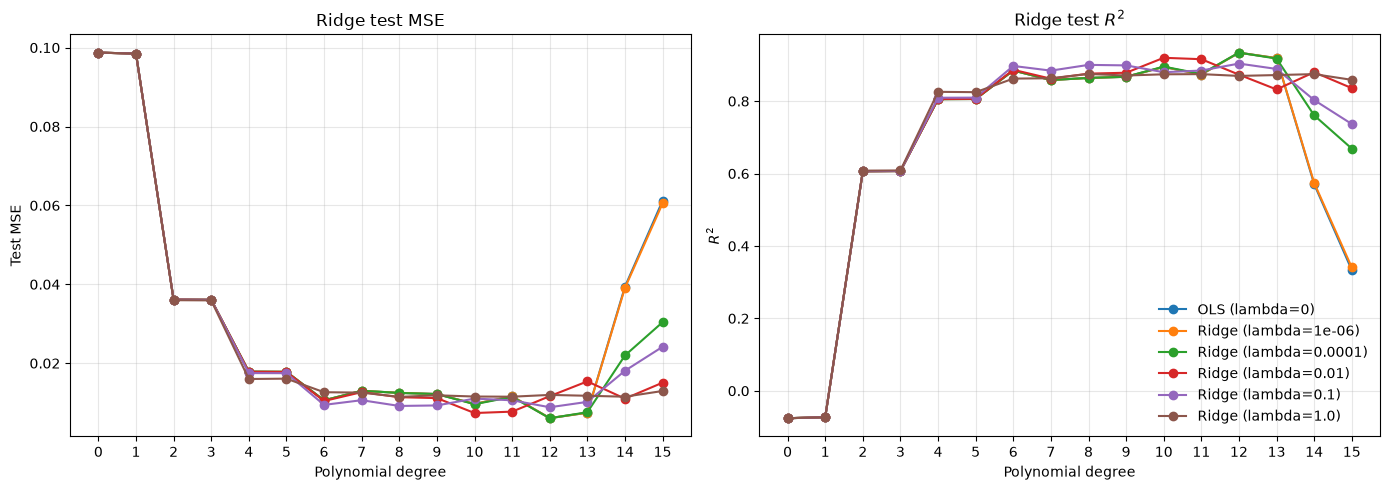

Best test MSE by penalty:
lambda       degree       test MSE       test R2
 0.0e+00           12       0.006079     0.933768
 1.0e-06           12       0.006079     0.933775
 1.0e-04           12       0.006055     0.934032
 1.0e-02           10       0.007368     0.919731
 1.0e-01           12       0.008835     0.903742
 1.0e+00            8       0.011464     0.875109


In [9]:
ridge_result = ridge_regression()
ridge_degrees = ridge_result["degrees"]

# OLS is lambda=0 case.
# Plot the noisy test MSE and R^2 to show how regularization affects the degree/variance tradeoff.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, lmbda in enumerate(ridge_result["lambdas"]):
    label = "OLS (lambda=0)" if lmbda == 0.0 else f"Ridge (lambda={lmbda})"
    axes[0].plot(ridge_degrees, ridge_result["test_mse"][idx], marker="o", label=label)
    axes[1].plot(ridge_degrees, ridge_result["test_r2"][idx], marker="o", label=label)
axes[0].set_title("Ridge test MSE")
axes[0].set_ylabel("Test MSE")
axes[1].set_title(r"Ridge test $R^2$")
axes[1].set_ylabel(r"$R^2$")
for axis in axes:
    axis.set_xlabel("Polynomial degree")
    axis.set_xticks(ridge_degrees)
    axis.grid(True, alpha=0.3)
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

# Report the best test degree for each penalty
print("Best test MSE by penalty:")
print("lambda       degree       test MSE       test R2")
for idx, lmbda in enumerate(ridge_result["lambdas"]):
    best_degree = np.argmin(ridge_result["test_mse"][idx])
    print(
        f"{lmbda:8.1e} {best_degree:12d}"
        f" {ridge_result['test_mse'][idx, best_degree]:14.6f}"
        f" {ridge_result['test_r2'][idx, best_degree]:12.6f}"
    )

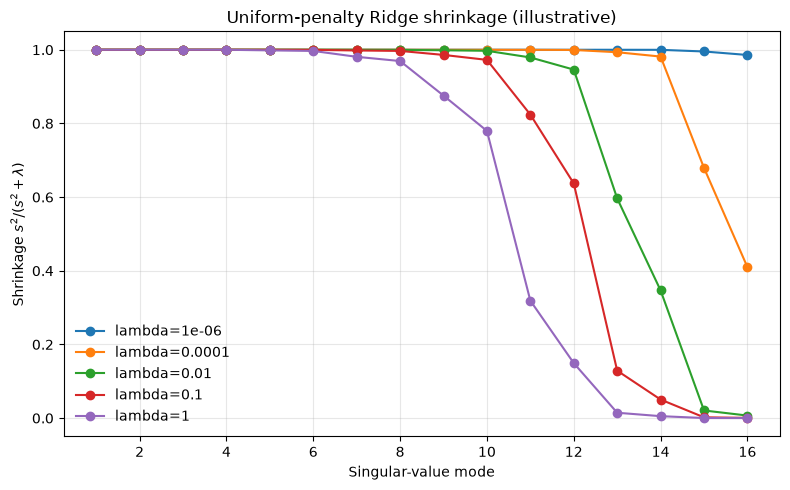

In [10]:
# Uniformly penalized Ridge has this simple singular-mode shrinkage.
# Our fitted Ridge exempts the intercept, so this is an illustration, not its exact mode decomposition.
X_degree15 = design_matrix(
    (ridge_result["x_train"] - ridge_result["mean_x"]) / ridge_result["std_dev_x"],
    15
)
singular_values = np.linalg.svd(X_degree15, compute_uv=False)
plt.figure(figsize=(8, 5))
for lmbda in ridge_result["lambdas"][1:]:
    shrinkage = singular_values**2 / (singular_values**2 + lmbda)
    plt.plot(np.arange(1, 17), shrinkage, "o-", label=rf"lambda={lmbda:g}")
plt.xlabel("Singular-value mode")
plt.ylabel(r"Shrinkage $s^2/(s^2+\lambda)$")
plt.title("Uniform-penalty Ridge shrinkage (illustrative)")
plt.grid(True, alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## Part c) The bias-variance tradeoff and bootstrap

In [11]:
# Bootstrap resamples are drawn from the training data
def bootstrap_bias_variance(n=config_n, sigma= config_sigma, max_degree=config_max_degree, n_bootstrap=200, test_size=config_test_size, seed=config_seed):
    """Estimate bias and variance of the degree polynomial model using bootstrap resampling."""
    x, y, y_actual = generate_data(n, sigma, seed)
    x_train, x_test, y_train, y_test, _, y_test_actual = train_test_split(x, y, y_actual, test_size=test_size, random_state=seed)
    x_train_scaled, x_test_scaled, mean_x, std_dev_x = scale_x(x_train, x_test)
    rng = np.random.default_rng(seed)
    # Evaluate bootstrap bias, variance, and prediction error on the same held-out grid.
    x_grid = x_test.copy()
    x_grid_scaled = (x_grid - mean_x) / std_dev_x
    runge_grid = runge(x_grid)
    degrees = np.array(list(range(max_degree + 1)), dtype=int)
    bias = np.empty(len(degrees))
    variance = np.empty(len(degrees))
    train_mse = np.empty(len(degrees))
    test_mse = np.empty(len(degrees))
    grid_mse = np.empty(len(degrees))
    for idx, degree in enumerate(degrees):
        X_grid = design_matrix(x_grid_scaled, degree)
        predictions = np.empty((n_bootstrap, len(x_grid)))
        test_predictions = np.empty((n_bootstrap, len(x_test)))
        bootstrap_train_mse = np.empty(n_bootstrap)
        for bootstrap_idx in range(n_bootstrap):
            sample = rng.integers(0, len(x_train), size=len(x_train))
            X_sample = design_matrix(x_train_scaled[sample], degree)
            coefficients = ols(X_sample, y_train[sample])
            predictions[bootstrap_idx] = X_grid @ coefficients
            X_test = design_matrix(x_test_scaled, degree)
            test_predictions[bootstrap_idx] = X_test @ coefficients
            bootstrap_train_mse[bootstrap_idx] = mse(y_train[sample], X_sample @ coefficients)
        mean_prediction = np.mean(predictions, axis=0)
        bias[idx] = np.mean((runge_grid - mean_prediction) ** 2)
        variance[idx] = np.mean(np.var(predictions, axis=0))
        train_mse[idx] = bootstrap_train_mse.mean()
        test_mse[idx] = np.mean((test_predictions - y_test) ** 2)
        grid_mse[idx] = np.mean((predictions - runge_grid) ** 2)
    return {
        "degrees": degrees,
        "bias": bias,
        "variance": variance,
        "noise": sigma ** 2,
        "train_mse": train_mse,
        "test_mse": test_mse,
        "grid_mse": grid_mse,
        "x_grid": x_grid,
        "runge_grid": runge_grid,
        "x_test": x_test,
        "y_test": y_test,
        "y_test_actual": y_test_actual
    }

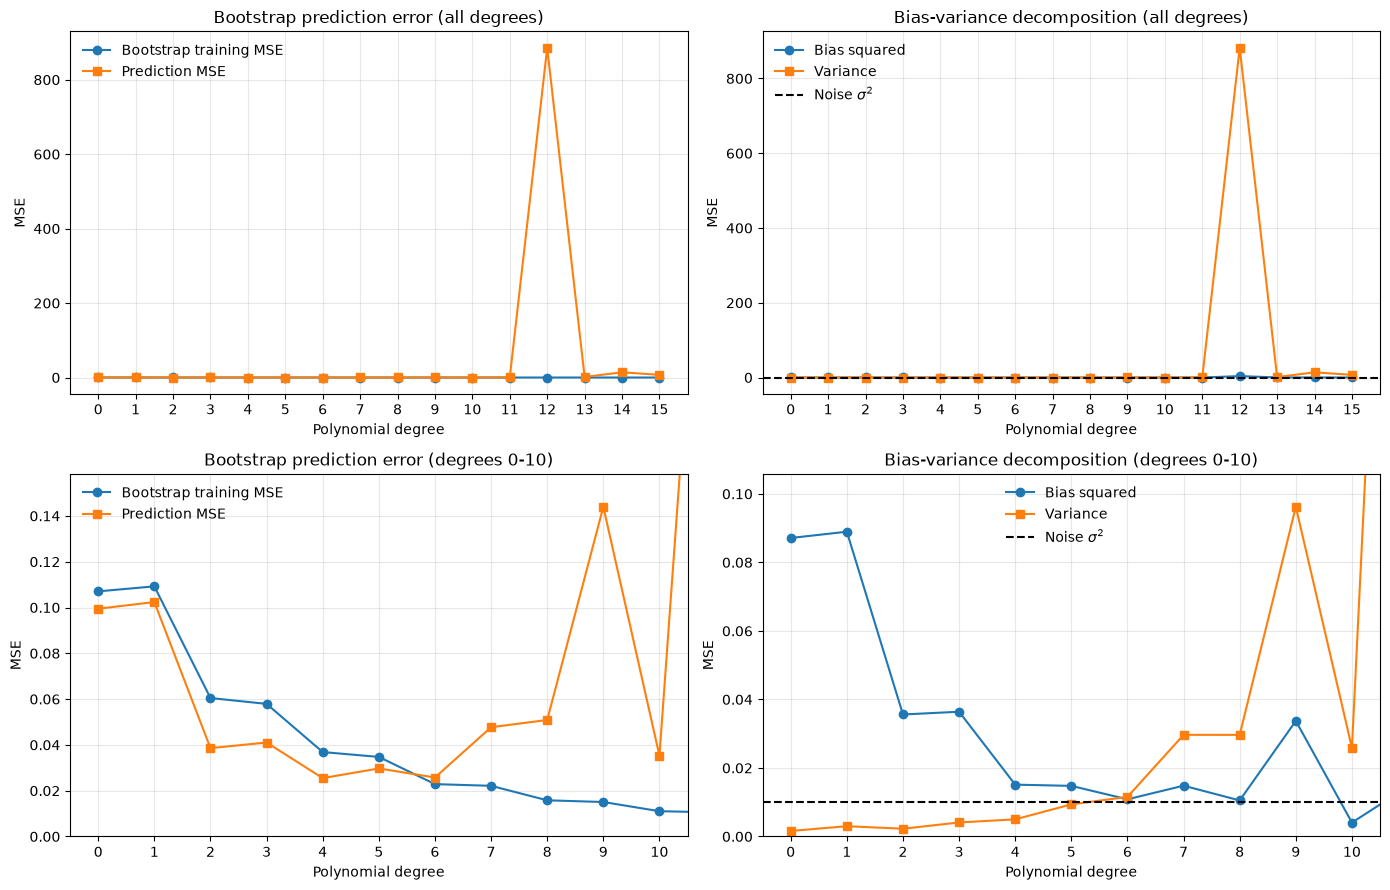

Lowest bootstrap prediction MSE degree: 4


In [12]:
bootstrap_results = bootstrap_bias_variance()
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for axis, zoom in zip(axes[0], axes[1]):
    for panel in (axis, zoom):
        panel.set(xlabel="Polynomial degree", ylabel="MSE")
        panel.grid(True, alpha=0.3)
axes[0, 0].set_title("Bootstrap prediction error (all degrees)")
axes[0, 1].set_title("Bias-variance decomposition (all degrees)")
axes[1, 0].set_title("Bootstrap prediction error (degrees 0-10)")
axes[1, 1].set_title("Bias-variance decomposition (degrees 0-10)")
for panel in (axes[0, 0], axes[1, 0]):
    panel.plot(bootstrap_results["degrees"], bootstrap_results["train_mse"], "o-", label="Bootstrap training MSE")
    panel.plot(bootstrap_results["degrees"], bootstrap_results["test_mse"], "s-", label="Prediction MSE")
for panel in (axes[0, 1], axes[1, 1]):
    panel.plot(bootstrap_results["degrees"], bootstrap_results["bias"], "o-", label="Bias squared")
    panel.plot(bootstrap_results["degrees"], bootstrap_results["variance"], "s-", label="Variance")
    panel.axhline(bootstrap_results["noise"], color="black", linestyle="--", label=r"Noise $\sigma^2$")
for axis in axes.flat:
    axis.legend(frameon=False)
    axis.set_xticks(bootstrap_results["degrees"])
for axis in axes[1]:
    axis.set_xlim(-0.5, 10.5)
axes[1, 0].set_ylim(0, 1.1 * max(bootstrap_results["test_mse"][:11].max(), bootstrap_results["train_mse"][:11].max()))
axes[1, 1].set_ylim(0, 1.1 * max(bootstrap_results["bias"][:11].max(), bootstrap_results["variance"][:11].max(), bootstrap_results["noise"]))
fig.tight_layout()
plt.show()
print("Lowest bootstrap prediction MSE degree:", bootstrap_results["degrees"][np.argmin(bootstrap_results["test_mse"])])

## Part d) Cross-validation

In [13]:
from sklearn.model_selection import KFold

def cross_validate(n=config_n, sigma=config_sigma, max_degree=config_max_degree, lambdas=config_lambdas, k_values=(5, 10), seed=config_seed):
    """L-fold cross-validation with fold-specific scaling."""
    x, y, _ = generate_data(n, sigma, seed)
    degrees = np.arange(max_degree + 1)
    lambdas = np.asarray(lambdas, dtype=float)
    scores = {}
    for k in k_values:
        folds = KFold(n_splits=k, shuffle=True, random_state=seed)
        ols_mse = np.zeros(len(degrees))
        ridge_mse = np.zeros((len(lambdas), len(degrees)))
        fold_count = 0
        for train_idx, test_idx in folds.split(x):
            x_train, x_test = x[train_idx], x[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            x_train_scaled, x_test_scaled, _, _ = scale_x(x_train, x_test)
            for degree in degrees:
                X_train = design_matrix(x_train_scaled, degree)
                X_test = design_matrix(x_test_scaled, degree)
                ols_prediction = predict(X_test, ols(X_train, y_train))
                ols_mse[degree] += mse(y_test, ols_prediction)
                for idx, lmbda in enumerate(lambdas):
                    coefficients = ridge(X_train, y_train, lmbda)
                    ridge_mse[idx, degree] += mse(y_test, predict(X_test, coefficients))
            fold_count += 1
        scores[k] = { "ols_mse": ols_mse / fold_count, "ridge_mse": ridge_mse / fold_count }
    return degrees, lambdas, scores


5-fold OLS best degree: 12
5-fold Ridge best lambda, degree: 1e-06 12
10-fold OLS best degree: 12
10-fold Ridge best lambda, degree: 0.0001 12
Bootstrap best degree: 4


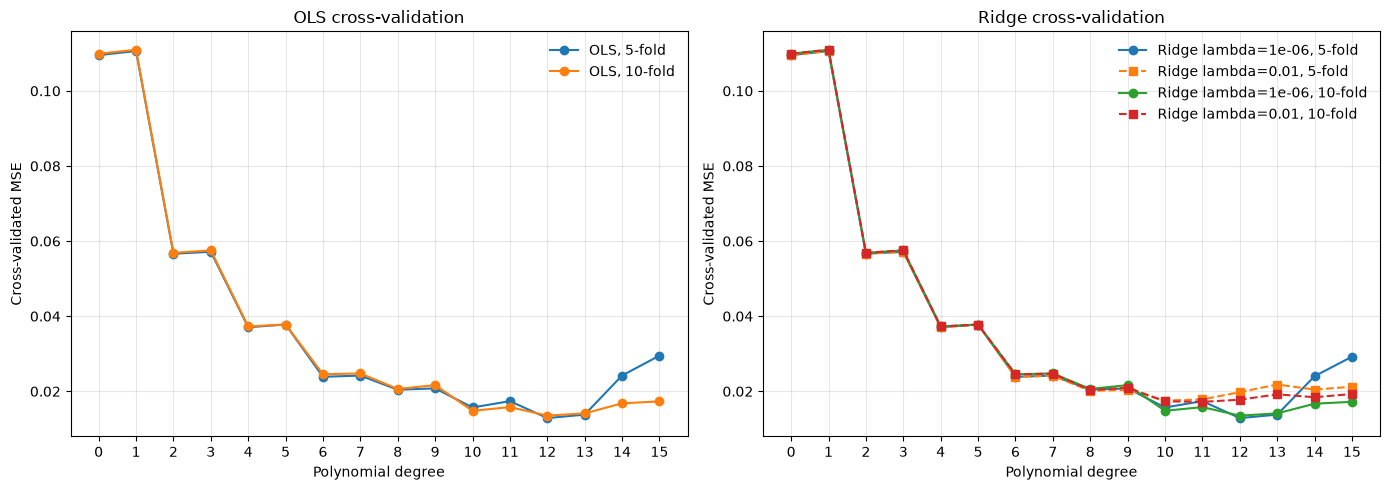

In [14]:
cv_degrees, cv_lambdas, cv_results = cross_validate()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for k, result in cv_results.items():
    axes[0].plot(cv_degrees, result["ols_mse"], "o-", label=f"OLS, {k}-fold")
    best = np.unravel_index(np.argmin(result["ridge_mse"]), result["ridge_mse"].shape)
    axes[1].plot(cv_degrees, result["ridge_mse"][1], "o-", label=f"Ridge lambda={cv_lambdas[1]:g}, {k}-fold")
    axes[1].plot(cv_degrees, result["ridge_mse"][3], "s--", label=f"Ridge lambda={cv_lambdas[3]:g}, {k}-fold")
    print(f"{k}-fold OLS best degree:", cv_degrees[np.argmin(result['ols_mse'])])
    print(f"{k}-fold Ridge best lambda, degree:", cv_lambdas[best[0]], cv_degrees[best[1]])
print("Bootstrap best degree:", bootstrap_results["degrees"][np.argmin(bootstrap_results["test_mse"])])
axes[0].set(xlabel="Polynomial degree", ylabel="Cross-validated MSE", title="OLS cross-validation")
axes[1].set(xlabel="Polynomial degree", ylabel="Cross-validated MSE", title="Ridge cross-validation")
for axis in axes:
    axis.set_xticks(cv_degrees)
    axis.grid(True, alpha=0.3)
    axis.legend(frameon=False)
fig.tight_layout()
plt.show()


> **LLM note:** ChatGPT assisted with debugging parts of the following implementation (Level 1). GitHub Copilot subsequently corrected the mini-batch Ridge penalty, implemented nested cross-validation and a converged Lasso comparison with stationarity checks, improved the bootstrap figure and sensitivity summaries, and generated the fresh-kernel execution/figure export runner. All code cells were rerun with the project virtual environment on 5 October 2026 (Level 2).

## Part e) Gradient descent

In [15]:
# Automatic differentiation check with JAX
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True) # as in numpy
rng = np.random.default_rng(config_seed)
x = np.sort(rng.uniform(-1, 1, config_n))
y = runge(x) + rng.normal(0, config_sigma, config_n)

# Starting point
degree, lmbda = 5, 1e-2
X = design_matrix(x, degree)

theta0 = rng.normal(size=X.shape[1])

def cost_ols(theta, X, y):
    return jnp.mean((y - X @ theta) ** 2)

def cost_ridge(theta, X, y, lmbda):
    return jnp.mean((y - X @ theta) ** 2) + lmbda / len(y) * jnp.sum(theta[1:] ** 2)

# gradients by automatic differentiation (with respect to argument 0 = theta)
grad_ols_ad = jax.grad(cost_ols)
grad_ridge_ad = jax.grad(cost_ridge)

# the same gradients by hand
grad_ols_analytic = 2.0 / len(y) * X.T @ (X @ theta0 - y)
grad_ridge_analytic = grad_ols_analytic.copy()
grad_ridge_analytic[1:] += 2.0 * lmbda / len(y) * theta0[1:]

print("OLS   max |AD - analytic| =", np.max(np.abs(grad_ols_ad(theta0, X, y) - grad_ols_analytic)))
print("Ridge max |AD - analytic| =", np.max(np.abs(grad_ridge_ad(theta0, X, y, lmbda) - grad_ridge_analytic)))


# the largest safe learning rate for plain gradient descent: eta < 2 / lambda_max(Hessian)
H = 2.0 / len(y) * X.T @ X
print("eta_max for OLS  =", 2.0 / np.linalg.eigvalsh(H).max())
H_ridge = H.copy()
H_ridge[1:, 1:] += 2.0 * lmbda / len(y) * np.eye(H.shape[0] - 1)
print("eta_max for Ridge =", 2.0 / np.linalg.eigvalsh(H_ridge).max())

OLS   max |AD - analytic| = 5.551115123125783e-17
Ridge max |AD - analytic| = 5.551115123125783e-17
eta_max for OLS  = 0.8937721839600539
eta_max for Ridge = 0.8937623265903589


In [16]:
# Part e): plain gradient descent with analytic and automatic gradients
# The penalty excludes the intercept, matching the closed-form Ridge code.
def grad_ols(theta, X, y):
    return 2.0 / len(y) * X.T @ (X @ theta - y)


def grad_ridge(theta, X, y, lmbda):
    gradient = grad_ols(theta, X, y)
    gradient = gradient.copy()
    gradient[1:] += 2.0 * lmbda / len(y) * theta[1:]
    return gradient


def gradient_descent(X, y, lmbda=0.0, learning_rate=None, max_iterations=100000,
                     tolerance=1e-10, gradient_function=grad_ols):
    if learning_rate is None:
        penalty = np.zeros((X.shape[1], X.shape[1]))
        penalty[1:, 1:] = 2.0 * lmbda / len(y) * np.eye(X.shape[1] - 1)
        hessian = 2.0 / len(y) * X.T @ X + penalty
        learning_rate = 1.0 / np.linalg.eigvalsh(hessian).max()
    theta = np.zeros(X.shape[1])
    for iteration in range(1, max_iterations + 1):
        if lmbda == 0:
            gradient = gradient_function(theta, X, y)
        else:
            gradient = gradient_function(theta, X, y, lmbda)
        updated_theta = theta - learning_rate * gradient
        if np.linalg.norm(updated_theta - theta) < tolerance:
            theta = updated_theta
            break
        theta = updated_theta
    return theta, iteration

result = polynomial_regression()

X_train_e = design_matrix((result["x_train"] - result["mean_x"]) / result["std_dev_x"], 5)
y_train_e = result["y_train"]
for lmbda in (0.0, 1e-2):
    gradient = grad_ols if lmbda == 0.0 else grad_ridge
    coefficients, iterations = gradient_descent(
        X_train_e, y_train_e, lmbda=lmbda, gradient_function=gradient
    )
    reference = ols(X_train_e, y_train_e) if lmbda == 0 else ridge(X_train_e, y_train_e, lmbda)
    print(f"lambda={lmbda:g}, iterations={iterations}, max coefficient error={np.max(np.abs(coefficients-reference)):.3e}")

import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
def cost_ols_e(theta, X, y):
    return jnp.mean((y - X @ theta) ** 2)
def cost_ridge_e(theta, X, y, lmbda):
    return jnp.mean((y - X @ theta) ** 2) + lmbda / len(y) * jnp.sum(theta[1:] ** 2)
test_theta = np.random.default_rng(7).normal(size=X_train_e.shape[1])
print("OLS AD error:", np.max(np.abs(np.asarray(jax.grad(cost_ols_e)(test_theta, X_train_e, y_train_e)) - grad_ols(test_theta, X_train_e, y_train_e))))
print("Ridge AD error:", np.max(np.abs(np.asarray(jax.grad(cost_ridge_e)(test_theta, X_train_e, y_train_e, 1e-2)) - grad_ridge(test_theta, X_train_e, y_train_e, 1e-2))))

# Compare gradient descent driven by automatic differentiation with the closed form.
for lmbda, gradient in ((0.0, grad_ols_ad), (1e-2, grad_ridge_ad)):
    coefficients, iterations = gradient_descent(
        X_train_e, y_train_e, lmbda=lmbda, gradient_function=gradient
    )
    reference = ols(X_train_e, y_train_e) if lmbda == 0 else ridge(X_train_e, y_train_e, lmbda)
    print(f"AD lambda={lmbda:g}, iterations={iterations}, max coefficient error={np.max(np.abs(coefficients-reference)):.3e}")

lambda=0, iterations=18012, max coefficient error=1.087e-07
lambda=0.01, iterations=17924, max coefficient error=1.082e-07


OLS AD error: 1.4210854715202004e-14
Ridge AD error: 1.4210854715202004e-14


AD lambda=0, iterations=18012, max coefficient error=1.087e-07


AD lambda=0.01, iterations=17924, max coefficient error=1.082e-07


## Part f) Momentum, AdaGrad, RMSprop and Adam

In [17]:
def optimize_quadratic(X, y, lmbda=0.0, method="plain", learning_rate=0.01,
                       max_iterations=20000, tolerance=1e-9, momentum=0.9):
    theta = np.zeros(X.shape[1])
    first_moment = np.zeros_like(theta)
    second_moment = np.zeros_like(theta)
    velocity = np.zeros_like(theta)
    epsilon = 1e-8
    for iteration in range(1, max_iterations + 1):
        gradient = grad_ridge(theta, X, y, lmbda)
        if method == "plain":
            step = gradient
        elif method == "momentum":
            velocity = momentum * velocity + gradient
            step = velocity
        elif method == "adagrad":
            second_moment += gradient ** 2
            step = gradient / (np.sqrt(second_moment) + epsilon)
        elif method == "rmsprop":
            second_moment = momentum * second_moment + (1 - momentum) * gradient ** 2
            step = gradient / (np.sqrt(second_moment) + epsilon)
        elif method == "adam":
            first_moment = momentum * first_moment + (1 - momentum) * gradient
            second_moment = 0.999 * second_moment + 0.001 * gradient ** 2
            first_corrected = first_moment / (1 - momentum ** iteration)
            second_corrected = second_moment / (1 - 0.999 ** iteration)
            step = first_corrected / (np.sqrt(second_corrected) + epsilon)
        else:
            raise ValueError(f"Unknown optimization method: {method}")
        updated_theta = theta - learning_rate * step
        if np.linalg.norm(updated_theta - theta) < tolerance:
            theta = updated_theta
            break
        theta = updated_theta
    return theta, iteration

methods = [("plain", 0.001), ("momentum", 0.001), ("adagrad", 0.05),
           ("rmsprop", 0.01), ("adam", 0.01)]
reference = ridge(X_train_e, y_train_e, 1e-2)
for method, learning_rate in methods:
    coefficients, iterations = optimize_quadratic(
        X_train_e, y_train_e, lmbda=1e-2, method=method, learning_rate=learning_rate
    )
    print(f"{method:8s}: iterations={iterations:5d}, coefficient error={np.linalg.norm(coefficients-reference):.3e}")
print("Learning-rate sensitivity for Adam:")
for learning_rate in (0.001, 0.003, 0.01, 0.03):
    coefficients, iterations = optimize_quadratic(
        X_train_e, y_train_e, lmbda=1e-2, method="adam", learning_rate=learning_rate
    )
    print(f"eta={learning_rate:g}: iterations={iterations}, coefficient error={np.linalg.norm(coefficients-reference):.3e}")

plain   : iterations=20000, coefficient error=8.754e-02
momentum: iterations=19282, coefficient error=1.904e-06


adagrad : iterations= 6962, coefficient error=6.052e-07
rmsprop : iterations=20000, coefficient error=1.225e-02
adam    : iterations=  692, coefficient error=2.393e-08
Learning-rate sensitivity for Adam:


eta=0.001: iterations=3593, coefficient error=8.548e-08
eta=0.003: iterations=1473, coefficient error=4.356e-08
eta=0.01: iterations=692, coefficient error=2.393e-08
eta=0.03: iterations=702, coefficient error=2.311e-08


## Part g) Lasso regression


In [18]:
def soft_threshold(values, threshold):
    return np.sign(values) * np.maximum(np.abs(values) - threshold, 0.0)


def lasso_proximal(X, y, lmbda=1e-3, learning_rate=None,
                   max_iterations=50000, tolerance=1e-10):
    theta = np.zeros(X.shape[1])
    if learning_rate is None:
        lipschitz = 2.0 * np.linalg.eigvalsh(X.T @ X).max() / len(y)
        learning_rate = 0.9 / lipschitz
    for iteration in range(1, max_iterations + 1):
        gradient = grad_ols(theta, X, y)
        candidate = theta - learning_rate * gradient
        candidate[1:] = soft_threshold(candidate[1:], learning_rate * lmbda)
        if np.linalg.norm(candidate - theta) < tolerance:
            theta = candidate
            break
        theta = candidate
    return theta, iteration

lasso_coefficients, lasso_iterations = lasso_proximal(X_train_e, y_train_e, lmbda=1e-3)
print("JAX derivative of abs at zero:", jax.grad(jnp.abs)(0.0))
print("Lasso iterations:", lasso_iterations)
print("Lasso nonzero coefficients:", np.count_nonzero(np.abs(lasso_coefficients[1:]) > 1e-8))
print("Lasso training MSE:", mse(y_train_e, predict(X_train_e, lasso_coefficients)))

JAX derivative of abs at zero: 1.0
Lasso iterations: 18304
Lasso nonzero coefficients: 5
Lasso training MSE: 0.0385160062400922


## Part h) Stochastic gradient descent

All batch sizes target MSE + (lambda / n_train) * sum(theta[1:]**2). Only the data gradient is averaged over the current batch. Equal epochs imply unequal numbers of updates, so the batch-size plot is not an equal-compute benchmark.

SGD coefficient error: 0.05306945122151651
SGD training MSE: 0.03866552069616744


batch_size=1, epochs=500, updates=40000, coefficient error=2.999270740
batch_size=8, epochs=500, updates=5000, coefficient error=0.056874468
batch_size=16, epochs=500, updates=2500, coefficient error=0.214427401
batch_size=40, epochs=500, updates=1000, coefficient error=0.527203080
batch_size=80, epochs=500, updates=500, coefficient error=0.713527744


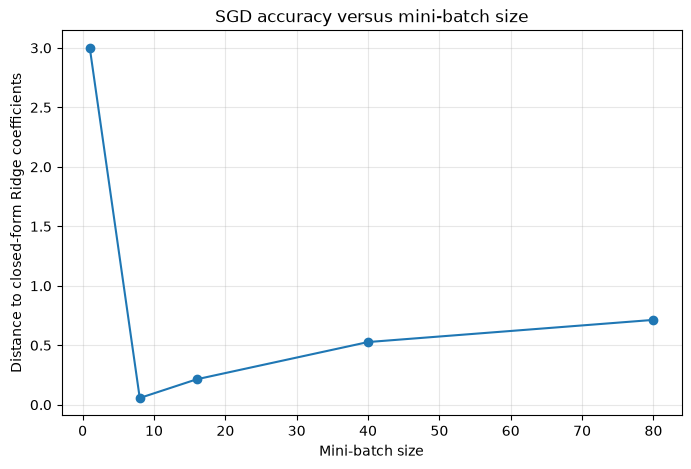

SGD epoch and learning-rate comparison:
epochs=100, eta=0.005, coefficient error=7.125e-01
epochs=500, eta=0.005, coefficient error=2.144e-01
epochs=1000, eta=0.005, coefficient error=5.307e-02
epochs=1000, eta=0.001, coefficient error=5.274e-01


In [19]:
def stochastic_gradient_descent(X, y, lmbda=0.0, batch_size=16, epochs=500, learning_rate=0.01, seed=config_seed):
    """Mini-batch SGD for the full-training-set Ridge objective."""
    if batch_size < 1 or epochs < 1 or learning_rate <= 0 or lmbda < 0:
        raise ValueError("Require positive batch size, epochs and learning rate, and non-negative lambda.")
    rng = np.random.default_rng(seed)
    theta = np.zeros(X.shape[1])
    n_train = len(y)
    for epoch in range(epochs):
        indices = rng.permutation(len(y))
        for start in range(0, len(y), batch_size):
            batch = indices[start:start + batch_size]
            X_batch, y_batch = X[batch], y[batch]
            gradient = grad_ols(theta, X_batch, y_batch)
            gradient[1:] += 2.0 * lmbda / n_train * theta[1:]
            theta -= learning_rate * gradient
    return theta

sgd_coefficients = stochastic_gradient_descent(
    X_train_e, y_train_e, lmbda=1e-2, batch_size=16, epochs=1000, learning_rate=0.005
)
sgd_reference = ridge(X_train_e, y_train_e, 1e-2)
print("SGD coefficient error:", np.linalg.norm(sgd_coefficients - sgd_reference))
print("SGD training MSE:", mse(y_train_e, predict(X_train_e, sgd_coefficients)))

batch_sizes = [1, 8, 16, 40, len(y_train_e)]
sgd_errors = []
for batch_size in batch_sizes:
    coefficients = stochastic_gradient_descent(
        X_train_e, y_train_e, lmbda=1e-2, batch_size=batch_size,
        epochs=500, learning_rate=0.005, seed=2026
    )
    sgd_errors.append(np.linalg.norm(coefficients - sgd_reference))
    updates = 500 * int(np.ceil(len(y_train_e) / batch_size))
    print(f"batch_size={batch_size}, epochs=500, updates={updates}, coefficient error={sgd_errors[-1]:.9f}")
plt.figure(figsize=(8, 5))
plt.plot(batch_sizes, sgd_errors, "o-")
plt.xlabel("Mini-batch size")
plt.ylabel("Distance to closed-form Ridge coefficients")
plt.title("SGD accuracy versus mini-batch size")
plt.grid(True, alpha=0.3)
plt.show()

print("SGD epoch and learning-rate comparison:")
for epochs, learning_rate in ((100, 0.005), (500, 0.005), (1000, 0.005), (1000, 0.001)):
    coefficients = stochastic_gradient_descent(
        X_train_e, y_train_e, lmbda=1e-2, batch_size=16,
        epochs=epochs, learning_rate=learning_rate, seed=2026
    )
    print(f"epochs={epochs}, eta={learning_rate:g}, coefficient error={np.linalg.norm(coefficients - sgd_reference):.3e}")

## Part i) Model selection and independent outer-fold evaluation

The earlier fixed-split test curves are exploratory, not final generalization estimates. Full-data CV below describes model selection only. Final performance uses 5 outer folds: each outer training set selects degree and penalty with 5 inner folds, refits with training-only scaling, and predicts the untouched outer fold. The candidate grid is fixed before this evaluation. Fold standard deviations describe partition variability, not confidence intervals. The proximal Lasso exercise above is separate from the LassoLars solver used in model selection; that solver's stationarity residual is checked for every fit.

Full-data CV selection only; these minima are not final evaluation scores:
Selected OLS: degree 12 CV MSE 0.013525749405278602
Selected Ridge: lambda 0.0001 degree 12 CV MSE 0.013309094857936087
Selected Lasso: lambda 1e-05 degree 12 CV MSE 0.01335312020911932
Full-data CV maximum Lasso KKT residual: 1.794e-07


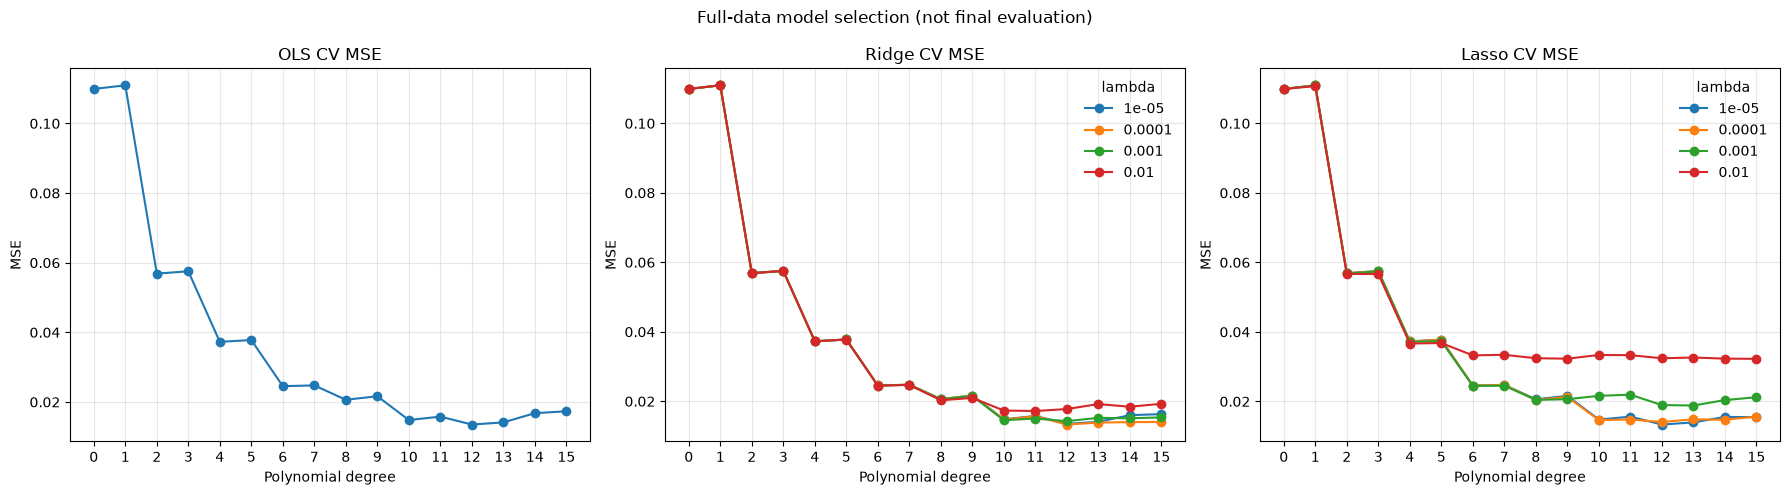

Outer fold 1: maximum inner Lasso KKT residual 1.495e-07
  OLS: degree=10, lambda=0, outer MSE=0.009695865
  Ridge: degree=11, lambda=0.001, outer MSE=0.010385282
  Lasso: degree=11, lambda=0.0001, outer MSE=0.009837555, Lasso KKT residual=1.858e-12


Outer fold 2: maximum inner Lasso KKT residual 1.210e-07
  OLS: degree=12, lambda=0, outer MSE=0.019340717
  Ridge: degree=12, lambda=1e-05, outer MSE=0.019288625
  Lasso: degree=12, lambda=1e-05, outer MSE=0.019032117, Lasso KKT residual=5.582e-12


Outer fold 3: maximum inner Lasso KKT residual 2.600e-09
  OLS: degree=12, lambda=0, outer MSE=0.007079810
  Ridge: degree=12, lambda=0.0001, outer MSE=0.006885978
  Lasso: degree=12, lambda=1e-05, outer MSE=0.006952752, Lasso KKT residual=8.889e-12


Outer fold 4: maximum inner Lasso KKT residual 2.099e-07
  OLS: degree=10, lambda=0, outer MSE=0.022368239
  Ridge: degree=10, lambda=0.001, outer MSE=0.024502412
  Lasso: degree=10, lambda=0.0001, outer MSE=0.024232784, Lasso KKT residual=2.085e-13


Outer fold 5: maximum inner Lasso KKT residual 1.121e-07
  OLS: degree=14, lambda=0, outer MSE=0.022553533
  Ridge: degree=15, lambda=1e-05, outer MSE=0.024139726
  Lasso: degree=15, lambda=1e-05, outer MSE=0.020338961, Lasso KKT residual=8.333e-08
Nested CV final evaluation (5 outer x 5 inner folds):
OLS: MSE=0.016207633, R2=0.849775045, fold MSE SD=0.007310267
Ridge: MSE=0.017040405, R2=0.842056270, fold MSE SD=0.008039581
Lasso: MSE=0.016078834, R2=0.850968857, fold MSE SD=0.007341601


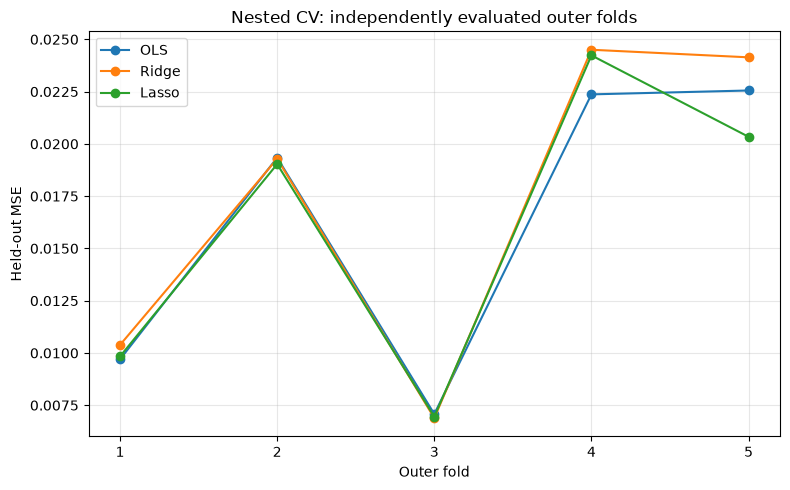

In [20]:
from sklearn.linear_model import LassoLars

def lasso_for_selection(X, y, lmbda):
    """Fit MSE + lambda * |theta[1:]|_1 with an unpenalized intercept."""
    if lmbda <= 0:
        raise ValueError("Lasso selection requires a positive penalty.")
    if X.shape[1] == 1:
        return np.array([np.mean(y)]), 0.0
    model = LassoLars(alpha=lmbda / 2, fit_intercept=True, eps=1e-12, max_iter=1000)
    model.fit(X[:, 1:], y)
    theta = np.r_[model.intercept_, model.coef_]
    gradient = grad_ols(theta, X, y)
    active = np.abs(theta[1:]) > 1e-10
    residual = np.maximum(np.abs(gradient[1:]) - lmbda, 0.0)
    residual[active] = np.abs(gradient[1:][active] + lmbda * np.sign(theta[1:][active]))
    max_residual = float(max(abs(gradient[0]), np.max(residual)))
    if model.n_iter_ >= model.max_iter or not np.isfinite(max_residual) or max_residual > 1e-6:
        raise RuntimeError(f"Lasso did not converge: degree={X.shape[1] - 1}, lambda={lmbda:g}, KKT residual={max_residual:g}")
    return theta, max_residual

def final_cross_validation(x, y, degrees, lambdas, k=10, seed=2026):
    """OLS, Ridge and Lasso model selection by cross-validation"""
    folds = KFold(n_splits=k, shuffle=True, random_state=seed)
    ols_scores = np.zeros(len(degrees))
    ridge_scores = np.zeros((len(lambdas), len(degrees)))
    lasso_scores = np.zeros((len(lambdas), len(degrees)))
    max_lasso_residual = 0.0
    for train_indices, validation_indices in folds.split(x):
        x_train, x_validation = x[train_indices], x[validation_indices]
        y_train, y_validation = y[train_indices], y[validation_indices]
        x_train_scaled, x_validation_scaled, _, _ = scale_x(x_train, x_validation)
        for degree_index, degree in enumerate(degrees):
            X_train = design_matrix(x_train_scaled, degree)
            X_validation = design_matrix(x_validation_scaled, degree)
            ols_scores[degree_index] += mse(
                y_validation, predict(X_validation, ols(X_train, y_train))
            )
            for lambda_index, lmbda in enumerate(lambdas):
                ridge_scores[lambda_index, degree_index] += mse(
                    y_validation, predict(X_validation, ridge(X_train, y_train, lmbda))
                )
                lasso_coefficients, residual = lasso_for_selection(X_train, y_train, lmbda)
                max_lasso_residual = max(max_lasso_residual, residual)
                lasso_scores[lambda_index, degree_index] += mse(
                    y_validation, predict(X_validation, lasso_coefficients)
                )
    number_of_folds = k
    return (ols_scores / number_of_folds, ridge_scores / number_of_folds,
            lasso_scores / number_of_folds, max_lasso_residual)


def nested_cross_validation(x, y, degrees, lambdas, outer_k=5, inner_k=5, seed=config_seed):
    """Evaluate model selection on outer folds never used for tuning."""
    predictions = {name: np.full(len(y), np.nan) for name in ("OLS", "Ridge", "Lasso")}
    selections = []
    outer_folds = KFold(n_splits=outer_k, shuffle=True, random_state=seed)
    for fold, (train_indices, test_indices) in enumerate(outer_folds.split(x), start=1):
        x_train, y_train = x[train_indices], y[train_indices]
        ols_scores, ridge_scores, lasso_scores, max_inner_residual = final_cross_validation(
            x_train, y_train, degrees, lambdas, k=inner_k, seed=seed + fold
        )
        ols_index = np.argmin(ols_scores)
        ridge_index = np.unravel_index(np.argmin(ridge_scores), ridge_scores.shape)
        lasso_index = np.unravel_index(np.argmin(lasso_scores), lasso_scores.shape)
        choices = {
            "OLS": (degrees[ols_index], 0.0),
            "Ridge": (degrees[ridge_index[1]], lambdas[ridge_index[0]]),
            "Lasso": (degrees[lasso_index[1]], lambdas[lasso_index[0]])
        }
        x_train_scaled, x_test_scaled, _, _ = scale_x(x_train, x[test_indices])
        print(f"Outer fold {fold}: maximum inner Lasso KKT residual {max_inner_residual:.3e}")
        for name, (degree, lmbda) in choices.items():
            X_train = design_matrix(x_train_scaled, degree)
            X_test = design_matrix(x_test_scaled, degree)
            residual = None
            if name == "OLS":
                coefficients = ols(X_train, y_train)
            elif name == "Ridge":
                coefficients = ridge(X_train, y_train, lmbda)
            else:
                coefficients, residual = lasso_for_selection(X_train, y_train, lmbda)
            predictions[name][test_indices] = predict(X_test, coefficients)
            fold_mse = mse(y[test_indices], predictions[name][test_indices])
            selections.append({"fold": fold, "model": name, "degree": int(degree),
                               "lambda": float(lmbda), "mse": fold_mse,
                               "lasso_kkt_residual": residual})
            diagnostic = f", Lasso KKT residual={residual:.3e}" if residual is not None else ""
            print(f"  {name}: degree={degree}, lambda={lmbda:g}, outer MSE={fold_mse:.9f}{diagnostic}")
    summary = {}
    for name, model_predictions in predictions.items():
        if not np.all(np.isfinite(model_predictions)):
            raise ValueError(f"Missing or non-finite outer predictions for {name}.")
        fold_scores = [row["mse"] for row in selections if row["model"] == name]
        summary[name] = {"mse": mse(y, model_predictions), "r2": r2(y, model_predictions),
                         "fold_std": float(np.std(fold_scores, ddof=1))}
    return predictions, selections, summary

x_final, y_final, _ = generate_data(n=100, sigma=0.1, seed=2026)
final_degrees = np.arange(16)
final_lambdas = np.array([1e-5, 1e-4, 1e-3, 1e-2])
final_ols, final_ridge, final_lasso, final_lasso_max_residual = final_cross_validation(
    x_final, y_final, final_degrees, final_lambdas
)
best_ols_degree = np.argmin(final_ols)
best_ridge = np.unravel_index(np.argmin(final_ridge), final_ridge.shape)
best_lasso = np.unravel_index(np.argmin(final_lasso), final_lasso.shape)
print("Full-data CV selection only; these minima are not final evaluation scores:")
print("Selected OLS: degree", final_degrees[best_ols_degree], "CV MSE", final_ols[best_ols_degree])
print("Selected Ridge: lambda", final_lambdas[best_ridge[0]], "degree", final_degrees[best_ridge[1]], "CV MSE", final_ridge[best_ridge])
print("Selected Lasso: lambda", final_lambdas[best_lasso[0]], "degree", final_degrees[best_lasso[1]], "CV MSE", final_lasso[best_lasso])
print(f"Full-data CV maximum Lasso KKT residual: {final_lasso_max_residual:.3e}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(final_degrees, final_ols, "o-")
axes[0].set_title("OLS CV MSE")
for lambda_index, lmbda in enumerate(final_lambdas):
    axes[1].plot(final_degrees, final_ridge[lambda_index], "o-", label=f"{lmbda:g}")
    axes[2].plot(final_degrees, final_lasso[lambda_index], "o-", label=f"{lmbda:g}")
axes[1].set_title("Ridge CV MSE")
axes[2].set_title("Lasso CV MSE")
fig.suptitle("Full-data model selection (not final evaluation)")
for axis in axes:
    axis.set_xlabel("Polynomial degree")
    axis.set_ylabel("MSE")
    axis.set_xticks(final_degrees)
    axis.grid(True, alpha=0.3)
axes[1].legend(title="lambda", frameon=False)
axes[2].legend(title="lambda", frameon=False)
fig.tight_layout()
plt.show()

outer_predictions, outer_selections, outer_summary = nested_cross_validation(
    x_final, y_final, final_degrees, final_lambdas
)
print("Nested CV final evaluation (5 outer x 5 inner folds):")
for name, metrics in outer_summary.items():
    print(f"{name}: MSE={metrics['mse']:.9f}, R2={metrics['r2']:.9f}, fold MSE SD={metrics['fold_std']:.9f}")
fig, axis = plt.subplots(figsize=(8, 5))
for name in outer_summary:
    rows = [row for row in outer_selections if row['model'] == name]
    axis.plot([row['fold'] for row in rows], [row['mse'] for row in rows], 'o-', label=name)
axis.set(xlabel='Outer fold', ylabel='Held-out MSE', title='Nested CV: independently evaluated outer folds')
axis.set_xticks(range(1, 6))
axis.grid(True, alpha=0.3)
axis.legend()
fig.tight_layout()
plt.show()